In [1]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [4]:
sample=pd.read_csv('../manifest/sample_mapping_20260507.csv')
sample.shape
sample.head(2)

,aliquot_barcode,source_barcode,sample_id
0,ECTRES-H2170-0001-TPX-A25-WGS-MSZHL2,H2170,NCI_25
1,ECTRES-H2170-0001-TPX-A29-WGS-HQRCV3,H2170,NCI_29


In [12]:
# purity=pd.read_csv('../summary/oncoanalyser/combined.purity.csv')
purity=pd.read_csv('../summary/oncoanalyser/parental/combined.purity.csv')
print(purity.shape)
purity.head(2)


(3, 26)


,aliquot_barcode,purity,normFactor,score,diploidProportion,ploidy,gender,status,polyclonalProportion,minPurity,maxPurity,minPloidy,maxPloidy,minDiploidProportion,maxDiploidProportion,somaticPenalty,wholeGenomeDuplication,msIndelsPerMb,msStatus,tml,tmlStatus,tmbPerMb,tmbStatus,svTumorMutationalBurden,runMode,targeted
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,1.0,0.5538,0.5280,0.0180,3.50,FEMALE,NORMAL,0.0820,1.0,1.0,3.45,3.55,0.0041,0.0297,0.0,True,0.3921,MSS,140,HIGH,11.8664,HIGH,1029,TUMOR,False
1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1.0,0.5392,1.3692,0.0001,3.85,MALE,NORMAL,0.4266,1.0,1.0,3.55,4.20,0.0000,0.0026,0.0,True,1.4963,MSS,325,HIGH,39.7310,HIGH,1084,TUMOR,False


In [13]:
purity = pd.merge(purity, sample, on='aliquot_barcode',how='left')

purity.head(2)

,aliquot_barcode,purity,normFactor,score,diploidProportion,ploidy,gender,status,polyclonalProportion,minPurity,maxPurity,minPloidy,maxPloidy,minDiploidProportion,maxDiploidProportion,somaticPenalty,wholeGenomeDuplication,msIndelsPerMb,msStatus,tml,tmlStatus,tmbPerMb,tmbStatus,svTumorMutationalBurden,runMode,targeted,source_barcode,sample_id
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,1.0,0.5538,0.5280,0.0180,3.50,FEMALE,NORMAL,0.0820,1.0,1.0,3.45,3.55,0.0041,0.0297,0.0,True,0.3921,MSS,140,HIGH,11.8664,HIGH,1029,TUMOR,False,EFM19,parental
1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1.0,0.5392,1.3692,0.0001,3.85,MALE,NORMAL,0.4266,1.0,1.0,3.55,4.20,0.0000,0.0026,0.0,True,1.4963,MSS,325,HIGH,39.7310,HIGH,1084,TUMOR,False,ECGI1,parental


In [15]:
col=['source_barcode', 'sample_id', 'purity', 'ploidy','minPloidy', 'maxPloidy', 'polyclonalProportion',  'wholeGenomeDuplication','tmbPerMb','svTumorMutationalBurden']

purity[purity['sample_id']=='parental'][col]

,source_barcode,sample_id,purity,ploidy,minPloidy,maxPloidy,polyclonalProportion,wholeGenomeDuplication,tmbPerMb,svTumorMutationalBurden
0,EFM19,parental,1.0,3.50,3.45,3.55,0.0820,True,11.8664,1029
1,ECGI1,parental,1.0,3.85,3.55,4.20,0.4266,True,39.7310,1084
2,H2170,parental,1.0,3.15,3.05,3.30,0.1268,True,23.1263,438


In [19]:
purple_segment=pd.read_csv('../summary/oncoanalyser/parental/combined.purple.segment.csv')
print(purple_segment.shape)

purple_segment = pd.merge(purple_segment, sample, on='aliquot_barcode',how='left')

print(purple_segment.head(2))


(9625, 27)
                        aliquot_barcode chromosome   start      end   
0  ECTRES-EFM19-0001-TPX-A01-WGS-2PV977          1       1   835000  \
1  ECTRES-EFM19-0001-TPX-A01-WGS-2PV977          1  835001  1660000   

  germlineStatus  bafCount  observedBAF  minorAlleleCopyNumber   
0        UNKNOWN         0          0.0                 0.0000  \
1        DIPLOID         0          0.0                 1.1056   

   minorAlleleCopyNumberDeviation  observedTumorRatio  observedNormalRatio   
0                          0.1000              0.0000                  1.0  \
1                          0.4414              0.6122                  1.0   

   unnormalisedObservedNormalRatio  majorAlleleCopyNumber   
0                              1.0                 0.0000  \
1                              1.0                 1.1056   

   majorAlleleCopyNumberDeviation  deviationPenalty  tumorCopyNumber   
0                          1.5000               0.0           0.0000  \
1            

In [23]:
purple_segment.to_csv('../summary/oncoanalyser/parental/combined.purple.segment_addsampleID.csv',index=False)


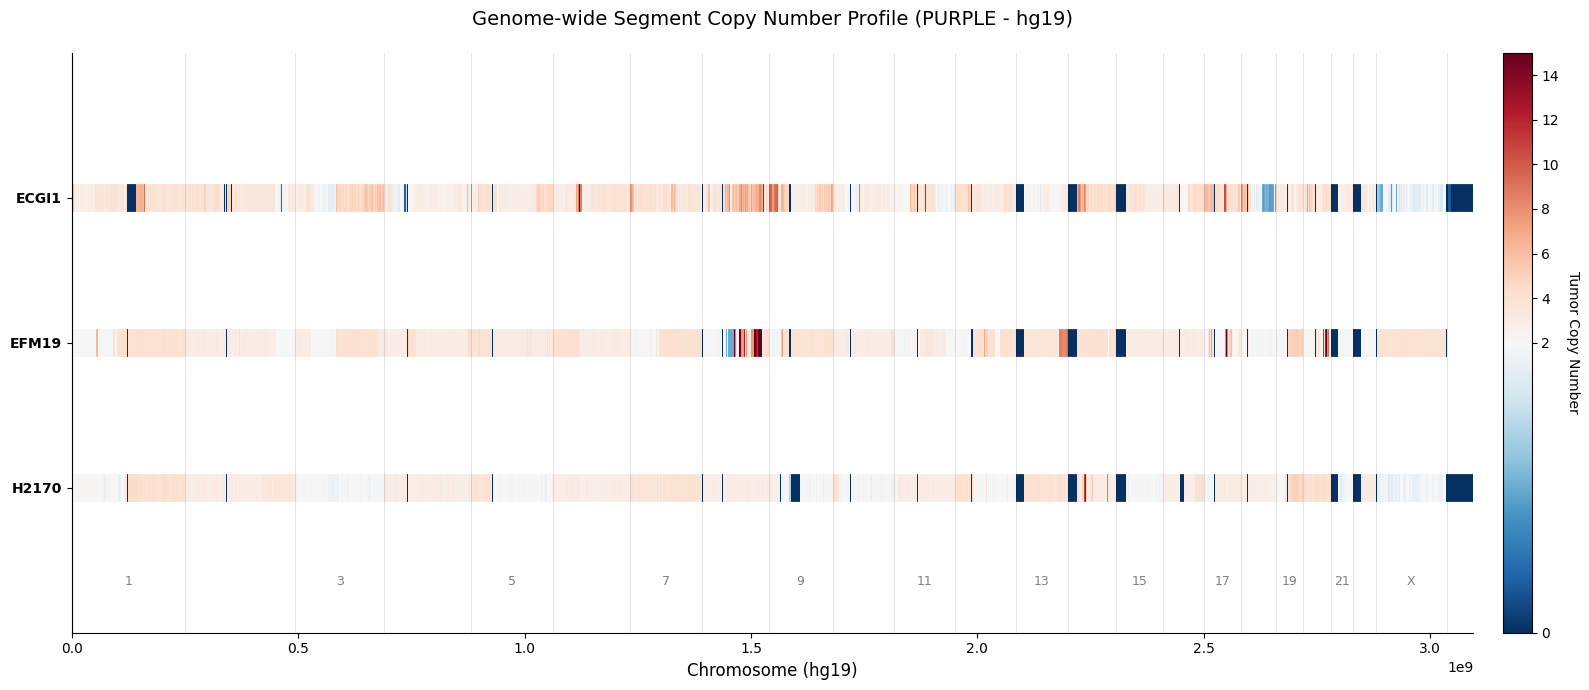

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.collections import LineCollection

# 1. hg19 (GRCh37) 염색체 길이 설정
chrom_lengths_hg19 = {
    '1': 249250621, '2': 243199373, '3': 198022430, '4': 191154276,
    '5': 180915260, '6': 171115067, '7': 159138663, '8': 146364022,
    '9': 141213431, '10': 135534747, '11': 135006516, '12': 133851895,
    '13': 115169878, '14': 107349540, '15': 102531392, '16': 90354753,
    '17': 81195210, '18': 78077248, '19': 59128983, '20': 63025520,
    '21': 48129895, '22': 51304566, 'X': 155270560, 'Y': 59373566
}

# 2. X축 오프셋 계산 (hg19 기준)
offsets = {}
current_offset = 0
for chrom, length in chrom_lengths_hg19.items():
    offsets[chrom] = current_offset
    current_offset += length

# 3. 데이터 전처리
df_plot = purple_segment.copy()
df_plot['chromosome'] = df_plot['chromosome'].astype(str).str.replace('chr', '')

# 지정하신 순서대로 샘플 배치
source_order = ['H2170', 'EFM19', 'ECGI1']
df_plot = df_plot[df_plot['source_barcode'].isin(source_order)]

# hg19 절대 좌표 계산
df_plot['abs_start'] = df_plot.apply(lambda x: x['start'] + offsets.get(x['chromosome'], 0), axis=1)
df_plot['abs_end'] = df_plot.apply(lambda x: x['end'] + offsets.get(x['chromosome'], 0), axis=1)

# 4. Plot 생성
fig, ax = plt.subplots(figsize=(16, 7))

# 컬러맵 설정: Diploid(2.0) 중심, 고증폭(15.0+)은 진한 빨강
norm = mcolors.TwoSlopeNorm(vcenter=2.0, vmin=0, vmax=15)
cmap = plt.get_cmap('RdBu_r') 

for i, source in enumerate(source_order):
    sample_data = df_plot[df_plot['source_barcode'] == source]
    
    if sample_data.empty:
        continue
        
    # [수정 포인트] LineCollection을 위한 세그먼트 좌표 리스트 생성
    # 각 세그먼트: [(x_start, y), (x_end, y)]
    segments = [
        [(row['abs_start'], i), (row['abs_end'], i)] 
        for _, row in sample_data.iterrows()
    ]
    
    # 각 세그먼트별 컬러 리스트 생성
    colors = [cmap(norm(min(cn, 15))) for cn in sample_data['tumorCopyNumber']]
    
    # LineCollection 객체 생성 및 추가 (hlines보다 훨씬 빠르고 에러에 안전함)
    lc = LineCollection(segments, colors=colors, linewidths=20, capstyle='butt')
    ax.add_collection(lc)

# 5. 데코레이션 및 라벨링
# LineCollection 사용 시 축 범위(Limit)를 수동으로 지정해줘야 합니다.
total_genomic_length = sum(chrom_lengths_hg19.values())
ax.set_xlim(0, total_genomic_length)
ax.set_ylim(-1, len(source_order))

ax.set_yticks(range(len(source_order)))
ax.set_yticklabels(source_order, fontweight='bold')
ax.set_xlabel('Chromosome (hg19)', fontsize=12)
ax.set_title('Genome-wide Segment Copy Number Profile (PURPLE - hg19)', fontsize=14, pad=20)

# 염색체 경계선 및 라벨 추가
for chrom, offset in offsets.items():
    ax.axvline(x=offset, color='black', linestyle='-', alpha=0.1, linewidth=0.8)
    if chrom in ['1', '3', '5', '7', '9', '11', '13', '15', '17', '19', '21', 'X']:
        mid_pos = offset + chrom_lengths_hg19[chrom] / 2
        ax.text(mid_pos, -0.6, chrom, ha='center', va='top', fontsize=9, color='gray')

# 컬러바 추가
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Tumor Copy Number', rotation=270, labelpad=15)

# 불필요한 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()